# Análisis de Componentes Principales (PCA) para Reducir la Dimensionalidad

### ¿Qué es PCA?

* Es una técnica muy usada para combatir la maldición de la dimensionalidad.
* `PCA (Principal Component Analysis / Análisis de Componentes Principales)` es una técnica de reducción de dimensionalidad que transforma un conjunto de variables en un nuevo conjunto de variables llamadas componentes principales.
* Estos componentes:
  - Son combinaciones lineales de las variables originales.
  - Están ordenados de forma que el primer componente explica la mayor variabilidad de los datos, el segundo componente explica la mayor variabilidad posible después del primero, y así sucesivamente.
  - Son ortogonales (independientes entre sí).

* ***¿Qué significa Eigen?***
  - `Eigen` = “propio” o “característico”.
  - En matemáticas se usa para hablar de valores propios (eigenvalues) y vectores propios (eigenvectors).

* ***Definición formal***

![MatrizEigen.png](MatrizEigen.png)


* ***¿Qué tiene que ver con PCA?***

![MatrizCovarianza.png](MatrizCovarianza.png)

* ***Conexión intuitiva***
  - Cada eigenvector de 𝐶 es un eje nuevo en el espacio de los datos.
  - Cada eigenvalue nos dice cuánta “información” (varianza) hay en esa dirección.
  - PCA ordena los ejes de mayor a menor eigenvalue, y nos quedamos con los primeros.

### ¿Para qué se usa PCA?

* Reducir dimensiones (de cientos o miles de variables a solo 2–3 sin perder mucha información).
* Visualización en 2D o 3D de datos originalmente de alta dimensión.
* Preprocesamiento antes de aplicar algoritmos como clustering o regresión, para reducir ruido.
* Evitar multicolinealidad (cuando varias variables están muy correlacionadas entre sí).
* ***¿Cómo funciona (intuición)?***
  - Calcula la media de los datos y centra los valores.
  - Obtiene la matriz de covarianza para ver cómo varían las variables juntas.
  - Calcula los autovalores y autovectores de esa matriz.
    1. Los `autovectores` son las direcciones de los componentes principales.
    2. Los `autovalores` indican cuánta varianza explica cada componente.
  - Ordena los componentes de mayor a menor varianza explicada.
  - Selecciona los primeros 𝑘 componentes (ej: los que explican el 90–95% de la varianza).

* ***Analogía de la lampara***
  - Imagina que tienes un objeto tridimensional (por ejemplo, un cubo) y le apuntas con una lámpara.
  - El objeto proyecta una sombra en la pared. Esa sombra es una representación en 2D del objeto 3D.
  - `Dependiendo de dónde pongas la lámpara, la sombra puede mostrar más o menos información de la forma real.`
  - El objeto 3D = tus datos originales en alta dimensión.
  - La sombra en 2D = los datos transformados a menos dimensiones (por ejemplo, pasar de 3D → 2D).
  - La posición de la lámpara = la orientación de los eigenvectores que el PCA encuentra.
  - `La sombra más “informativa” es la proyección sobre la dirección donde hay más varianza (PC1).`
  - `PCA busca el mejor ángulo de la lámpara para que la sombra conserve la mayor cantidad de información del objeto original con el menor número de dimensiones.`

### Ejemplos ilustrativo.

Tenemos los datos:  

$$
X =
\begin{bmatrix}
2 & 0 \\ 
0 & 2 \\
3 & 1
\end{bmatrix}
$$

---

1) ***Media y centrado***

`Media de cada variable`:  

$$
\mu = \left( \frac{2+0+3}{3}, \frac{0+2+1}{3} \right) = (1.6667, 1.0)
$$

`Datos centrados`:  

$$
X_c = X - \mu =
\begin{bmatrix}
0.3333 & -1.0 \\
-1.6667 & 1.0 \\
1.3333 & 0.0
\end{bmatrix}
$$

---

2) ***Matriz de covarianza***

$$
C = \frac{1}{n-1} X_c^\top X_c \qquad (n=3)
$$

$$
X_c =
\begin{bmatrix}
1/3 & -1.0 \\
-5/3 & 1.0 \\
4/3 & 0.0
\end{bmatrix}
$$

$$
X_c^\top =
\begin{bmatrix}
1/3 & -5/3 & 4/3 \\
-1.0 & 1.0 & 0.0 
\end{bmatrix}
$$

`Resultado del producto matricial (3x2) * (2*3) = 2x2`

$$
X_c^\top * X_c =
\begin{bmatrix}
14/3 & -1.0 \\
-1.0 & 1.0
\end{bmatrix}
$$


$$
C =
\begin{bmatrix}
2.3333 & -1.0 \\
-1.0 & 1.0
\end{bmatrix}
$$

---

3) ***Eigenvalues y eigenvectors***

Resolvemos la ecuación característica:

$$
\det(C - \lambda I) = 0
$$

Con la matriz de covarianza:

$$
C =
\begin{bmatrix}
2.3333 & -1.0 \\
-1.0 & 1.0
\end{bmatrix}
$$

Entonces:

$$
\det
\begin{bmatrix}
2.3333 - \lambda & -1.0 \\
-1.0 & 1.0 - \lambda
\end{bmatrix}
= 0
$$

Desarrollando el determinante:

$$
(2.3333 - \lambda)(1.0 - \lambda) - (-1.0)(-1.0) = 0
$$

$$
\lambda^2 - 3.3333\lambda + 1.3333 = 0
$$

Resolviendo la cuadrática:

$$
\lambda_1 \approx 2.8685, \quad \lambda_2 \approx 0.4648
$$

---

Para encontrar los eigenvectores resolvemos:

$$
(C - \lambda I)v = 0
$$

Para $\lambda_1 \approx 2.8685$:

$$
\begin{bmatrix}
2.3333 - 2.8685 & -1.0 \\
-1.0 & 1.0 - 2.8685
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2
\end{bmatrix}
= 0
$$

De aquí se obtiene (normalizando):

$$
v_1 \approx 
\begin{bmatrix}
0.8817 \\
-0.4719
\end{bmatrix}
$$

---

Para $\lambda_2 \approx 0.4648$:

$$
\begin{bmatrix}
2.3333 - 0.4648 & -1.0 \\
-1.0 & 1.0 - 0.4648
\end{bmatrix}
\begin{bmatrix}
v_1 \\
v_2
\end{bmatrix}
= 0
$$

De aquí se obtiene (normalizando):

$$
v_2 \approx
\begin{bmatrix}
0.4719 \\
0.8817
\end{bmatrix}
$$

---

4) ***Proyección de los datos en PC1***

$$
Z = X_c v_1
$$

$$
Z \approx
\begin{bmatrix}
0.7657 \\
-1.9413 \\
1.1756
\end{bmatrix}
$$

---

5) ***Reconstrucción usando solo PC1***

$$
\hat{X} = Z v_1^\top + \mu
$$

$$
\hat{X} \approx
\begin{bmatrix}
2.3418 & 0.6387 \\
-0.0449 & 1.9160 \\
2.7031 & 0.4453
\end{bmatrix}
$$

Comparado con los datos originales:

$$
X =
\begin{bmatrix}
2 & 0 \\
0 & 2 \\
3 & 1
\end{bmatrix}
$$

### Conclusión

* El PCA encontró que la información de los datos se concentra mayormente en una sola dirección (𝑣1), lo que permite reducir de 2D a 1D conservando ~86% de la varianza.
* Esto es justo lo que hace útil al PCA: simplificar datos, eliminar redundancia y mantener la esencia de la variación.

### Ejercicio

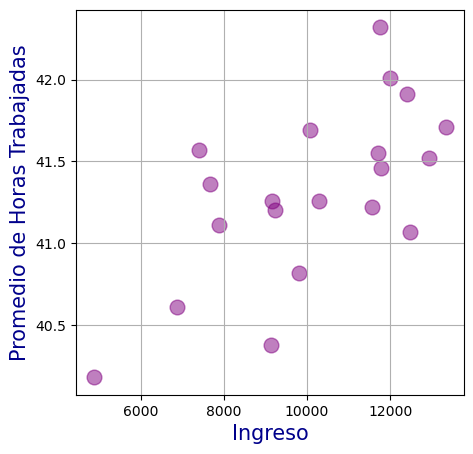

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

datos = {"ingreso" : [9136.81, 11709.94, 12416.79, 4875.73, 10065.03,
                      11755.33, 7401.78, 10291.38, 12002.42, 11787.76,
                      13347.65, 7676.76, 9808.56, 11556.47, 7875.49,
                      12486.19, 9242.40, 6867.09, 12946.25, 9167.36],

         "horas_trabajadas" : [40.38, 41.55, 41.91, 40.18, 41.69,
                               42.32, 41.57, 41.26, 42.01, 41.46,
                               41.71, 41.36, 40.82, 41.22, 41.11,
                               41.07, 41.20, 40.61, 41.52, 41.26]}

datos = pd.DataFrame(datos)

# Código de visualización
fig = plt.figure(figsize=(5, 5))
plt.scatter(datos["ingreso"], datos["horas_trabajadas"], 
            marker=".", s=450, color="purple", alpha=0.5)
plt.xlabel("Ingreso", fontsize=15, color="darkblue")
plt.ylabel("Promedio de Horas Trabajadas", fontsize=15, color="darkblue")
plt.grid(visible=True)
plt.show()

### Reducción de dimensionalidad con PCA

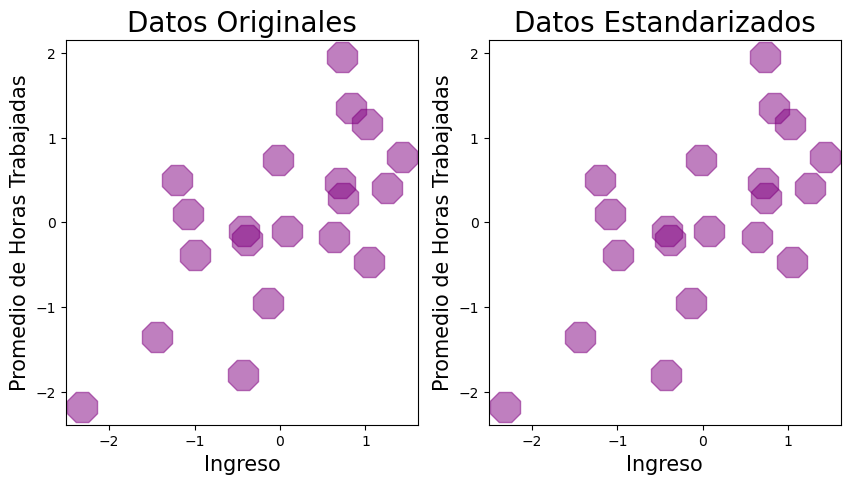

In [12]:
from sklearn.preprocessing import StandardScaler

### Paso 1: Estandarizar los datos

# Código de visualización

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.set_title("Datos Originales", fontsize=20)
ax1.scatter(datos["ingreso"], datos["horas_trabajadas"], 
            marker="8", s=550, color="purple", alpha=0.5)
ax1.set_xlabel("Ingreso", fontsize=15)
ax1.set_ylabel("Promedio de Horas Trabajadas", fontsize=15)

# Estandarización de los datos
datos = pd.DataFrame(StandardScaler().fit_transform(datos),
                     columns=["ingreso", "horas_trabajadas"])


# Código de visualización
ax2.set_title("Datos Estandarizados", fontsize=20)
ax2.scatter(datos["ingreso"], datos["horas_trabajadas"], 
            marker="8", s=550, color="purple", alpha=0.5)
ax2.set_xlabel("Ingreso", fontsize=15)
ax2.set_ylabel("Promedio de Horas Trabajadas", fontsize=15)
plt.show()

                   ingreso  horas_trabajadas
ingreso           1.052632          0.682360
horas_trabajadas  0.682360          1.052632


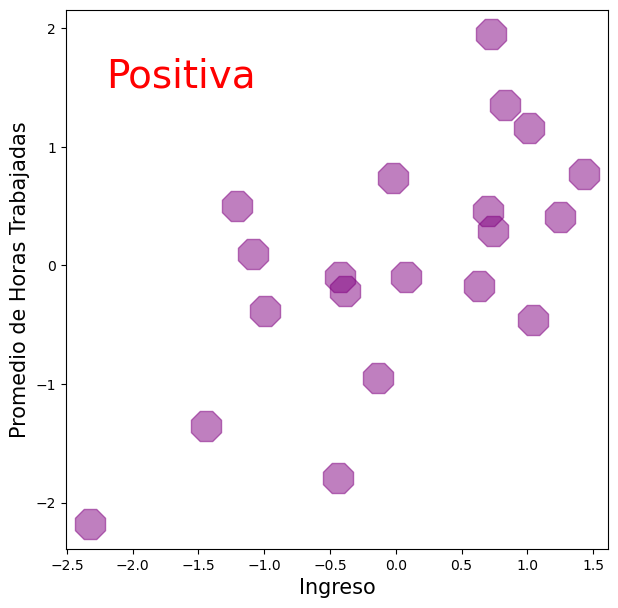

In [13]:
### Paso 2: Matriz de covarianza
print(datos.cov())

# Código de visualización

plt.figure(figsize=(7, 7))
plt.scatter(datos["ingreso"], datos["horas_trabajadas"], 
            marker="8", s=550, color="purple", alpha=0.5)
plt.xlabel("Ingreso", fontsize=15)
plt.ylabel("Promedio de Horas Trabajadas", fontsize=15)
plt.text(-2.2, 1.5, "Positiva", fontsize=28, color="red")
plt.show()

Eigenvector Rojo: [-0.70710678 -0.70710678] Eigenvalor: 1.734991434394586
Eigenvector Azul: [-0.70710678  0.70710678] Eigenvalor: 0.3702717235001506


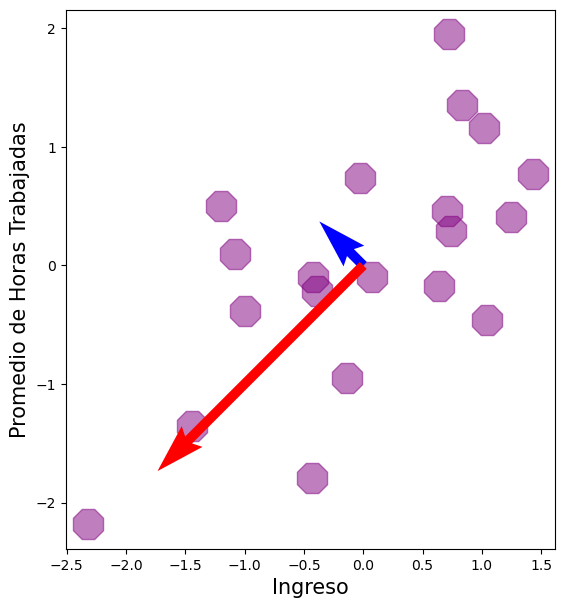

In [14]:
### Paso 3: Eigenvalores & Eigenvectores
from numpy.linalg import eig

# Calcular eigenvalores y eigenvectores
valores, vectores = eig(datos.cov())

vector_azul = vectores[:, 0]
vector_rojo = vectores[:, 1]

print("Eigenvector Rojo:", vector_rojo, "Eigenvalor:", valores[1])
print("Eigenvector Azul:", vector_azul, "Eigenvalor:", valores[0])

# Código de visualización

plt.figure(figsize=(7, 7))
plt.axes().set_aspect("equal")

# Graficando los datos
plt.scatter(datos["ingreso"], datos["horas_trabajadas"], 
            marker="8", s=550, color="purple", alpha=0.5)

# Graficando los eigenvectores
plt.quiver(0, 0, 
           vector_azul[0]/abs(vector_azul[0])*valores[0],
           vector_azul[1]/abs(vector_azul[1])*valores[0],
           color="blue", angles="xy", scale_units="xy", scale=1, width=0.02)

plt.quiver(0, 0, 
           vector_rojo[0]/abs(vector_rojo[0])*valores[1],
           vector_rojo[1]/abs(vector_rojo[1])*valores[1],
           color="red", angles="xy", scale_units="xy", scale=1, width=0.02)

plt.xlabel("Ingreso", fontsize=15)
plt.ylabel("Promedio de Horas Trabajadas", fontsize=15)
plt.show()

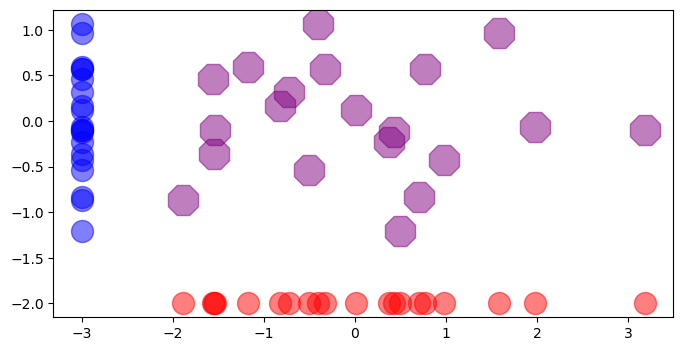

In [15]:
### Paso 4: Proyecta datos
proyectados = pd.DataFrame(datos.values @ vectores.T, 
                          columns=["ingreso", "horas_trabajadas"])

# Código de visualización
plt.figure(figsize=(8, 8))
plt.axes().set_aspect("equal")

# Datos rotados
plt.scatter(proyectados["ingreso"], proyectados["horas_trabajadas"], 
            marker="8", s=550, color="purple", alpha=0.5)

# Proyección de los datos en 1 dimensión
plt.scatter(proyectados["ingreso"], [-2]*len(proyectados["ingreso"]), 
            s=250, color="red", alpha=0.5)

plt.scatter([-3]*len(proyectados["horas_trabajadas"]), proyectados["horas_trabajadas"], 
            s=250, color="blue", alpha=0.5)
plt.show()

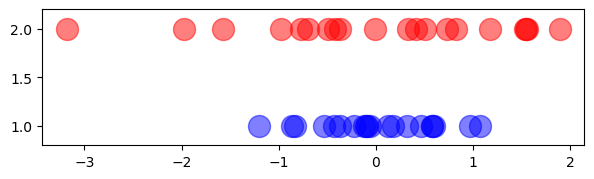

Varianza explicada por cada componente: [1.73499143 0.37027172]
Proporción de varianza explicada por cada componente: [0.82412093 0.17587907]


In [16]:
### Paso 5: Selecciona los componentes
from sklearn.decomposition import PCA

# Obtención de componentes principales
pca = PCA()
datos = pca.fit_transform(datos)

# Código de visualización
plt.figure(figsize=(7, 7))
plt.axes().set_aspect("equal")
plt.scatter(datos[:, 0], [2]*datos[:, 0].size, s=250, color="red", alpha=0.5)
plt.scatter(datos[:, 1], [1]*datos[:, 1].size, s=250, color="blue", alpha=0.5)
plt.ylim((0.8, 2.2))
plt.show()
print("Varianza explicada por cada componente:", pca.explained_variance_)
print("Proporción de varianza explicada por cada componente:", pca.explained_variance_ratio_)